In [1]:
import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import csv
import file
import sys
import os

In [2]:
path_algo = 'algo_perf/'

relu_data = np.loadtxt(path_algo + 'relu.csv', delimiter=',')
relu_data = relu_data[1:]
relu_mean = np.mean(relu_data, axis=0)
relu_std = np.std(relu_data, axis=0)


elu_data = np.loadtxt(path_algo + 'elu.csv', delimiter=',')
elu_data = elu_data[1:]
elu_mean = np.mean(elu_data, axis=0)
elu_std = np.std(elu_data, axis=0)


In [3]:
data_theory_2 = {sig: file.csv_to_dict(f'data/{sig}/W_rad/Delta_0.1/v_ones/unified.csv') for sig in ['relu', 'elu']}

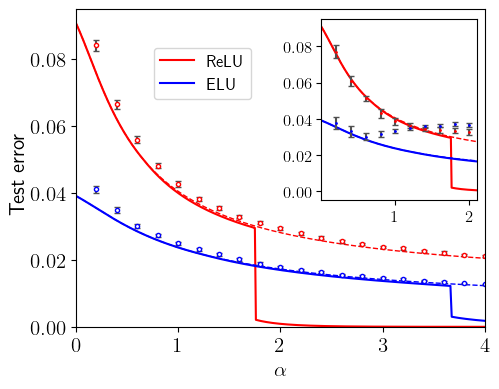

In [10]:
width, height = 5, 4
big, small = int(width*3), int(width*2.4)
fig, ax = plt.subplots(figsize=(width, height), tight_layout=True)


ax.set_xticks([0,1,2,3,4])
ax.tick_params(axis='both', labelsize=big)
ax.set_xlabel(r'$\alpha$', fontsize=big)
ax.set_xlim(0, 4)
ax.set_ylim(0, 0.095)

inset_ax = ax.inset_axes([0.60, 0.40, 0.38, 0.57])  
inset_ax.set_xlim(0, 2.1)
inset_ax.set_xticks([1, 2])
inset_ax.tick_params(axis='both', labelsize=small)


# theoretical curves
for sig, color, label in zip(['relu', 'elu'], ['r', 'b'], ['ReLU', 'ELU']):
    alphas = data_theory_2[sig]['alpha']
    mmses = data_theory_2[sig]['mmse']
    mmses_uni = data_theory_2[sig]['mmse_uni']
    ax.plot(alphas, mmses, color=color, label=label)
    ax.plot(alphas, mmses_uni, color=color, linestyle='--', linewidth=1)
    inset_ax.plot(alphas, mmses, color=color, label=label)
    inset_ax.plot(alphas, mmses_uni, color=color, linestyle='--', linewidth=1)

# AMP data
alphas = np.linspace(0.2, 4, 20)
# ax.scatter(alphas, relu_mean, marker='o', edgecolors='red', facecolors='none', s=10)
# ax.scatter(alphas, elu_mean, marker='o', edgecolors='blue', facecolors='none', s=10)
ax.errorbar(alphas, relu_mean, yerr=relu_std, fmt='o', markersize=3, markerfacecolor='white', markeredgecolor='red', capsize=2, color='red', ecolor='#505050')
ax.errorbar(alphas, elu_mean, yerr=elu_std, fmt='o', markersize=3, markerfacecolor='white', markeredgecolor='blue', capsize=2, color='blue', ecolor='#505050')
ax.legend(loc="lower left", bbox_to_anchor=(0.17, 0.69), fontsize=small)

# MCMC data
result = file.csv_to_dict(f'data/relu/W_rad/Delta_0.1/v_ones/result.csv')
inset_ax.errorbar(result['alpha'], result['mean_mmse'], yerr=result['std_mmse'], fmt='o', markersize=1, capsize=2, color='red', ecolor='#505050')
result = file.csv_to_dict(f'data/elu/W_rad/Delta_0.1/v_ones/result.csv')
inset_ax.errorbar(result['alpha'], result['mean_mmse'], yerr=result['std_mmse'], fmt='o', markersize=1, capsize=2, color='blue', ecolor='#505050')

fig.tight_layout(rect=[0.02, 0, 1, 1])
fig.text(0.01, 0.55, "Test error", fontsize=big, va='center', rotation='vertical')
plt.savefig('fig_rad_2.pdf')
plt.show()